In [1]:
import MDAnalysis as mda
import prolif as plf
from rdkit import Chem
import os
from collections import defaultdict
import pandas as pd
import sys
import json
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/MDAnalysis/topology/tables.py:52: DeprecationWarning: Deprecated in version 2.8.0
MDAnalysis.topology.tables has been moved to MDAnalysis.guesser.tables. This import point will be removed in MDAnalysis version 3.0.0
  warnings.warn(wmsg, category=DeprecationWarning)


# Loading and cleaning data

In [2]:
# Import all pickled IFP dictionaries from prolif_fps directory

IFP_pickles = [file for file in os.listdir('./prolif_fps') if file.endswith('.pkl')]

IFP_dicts = {}

for pickle in IFP_pickles:
    temp_dict = pd.read_pickle(f"./prolif_fps/{pickle}")
    key = list(temp_dict.keys())[0]
    IFP_dicts[key] = temp_dict[key]



# Clean up column levels

for run_key, run_dict in IFP_dicts.items():
    for conformer_key, conformer_dict in IFP_dicts[run_key].items():
        for ligand_key, ligand_list in IFP_dicts[run_key][conformer_key].items():
            # remove superfluous ligand columns level 
            ligand_list[1].columns = ligand_list[1].columns.droplevel("ligand")
            # merge protein and interaction column level
            ligand_list[1].columns = ligand_list[1].columns.map("_".join)
            if "_" in ligand_list[1].columns:
                ligand_list[1].rename(columns={'_': 'LigName'}, inplace=True)

## Summary stats of IFP counts, enrichments

In [4]:
IFP_frequencies = {}

for run_key, run_dict in IFP_dicts.items():
    IFP_frequencies[run_key] = {}

    for conformer_key, conformer_dict in IFP_dicts[run_key].items():

        ligand_keys = list(conformer_dict.keys())
        actives_key = [key for key in ligand_keys if key.endswith("true_actives.sdf")][0]
        inactives_key = [key for key in ligand_keys if key.endswith("true_inactives.sdf")][0]
        decoys_key = [key for key in ligand_keys if key.endswith("decoys.sdf")][0]

        actives = IFP_dicts[run_key][conformer_key][actives_key][1].copy()
        if 'LigName' in actives.columns:
            actives.drop('LigName', axis=1, inplace=True)
        freq_actives = actives.mean(axis=0)
        freq_actives.name = 'freq_actives'

        inactives = IFP_dicts[run_key][conformer_key][inactives_key][1].copy()
        if 'LigName' in inactives.columns:
            inactives.drop('LigName', axis=1, inplace=True)
        freq_inactives = inactives.mean(axis=0)
        freq_inactives.name = 'freq_inactives'

        decoys = IFP_dicts[run_key][conformer_key][decoys_key][1].copy()
        if 'LigName' in decoys.columns:
            decoys.drop('LigName', axis=1, inplace=True)
        freq_decoys = decoys.mean(axis=0)
        freq_decoys.name = 'freq_decoys'

        new_df = pd.concat(
            [
                freq_actives.rename("freq_actives"),
                freq_inactives.rename("freq_inactives"),
                freq_decoys.rename("freq_decoys"),

            ],
            axis = 1
        )

        new_df['ER_actives_decoys'] = new_df['freq_actives'] / new_df['freq_decoys']
        new_df['Log2_ER_actives_decoys'] = np.log2(new_df['ER_actives_decoys'])

        new_df['ER_actives_inactives'] = new_df['freq_actives'] / new_df['freq_inactives']
        new_df['Log2_ER_actives_inactives'] = np.log2(new_df['ER_actives_inactives'])
        
        IFP_frequencies[run_key][conformer_key] = new_df



In [5]:
IFP_frequencies['12Jun_rg']['4h2i_c_4_dimer_sdf']

,freq_actives,freq_inactives,freq_decoys,ER_actives_decoys,Log2_ER_actives_decoys,ER_actives_inactives,Log2_ER_actives_inactives
LEU363.A_VdWContact,0.070175,0.059524,0.161109,0.435578,-1.198997,1.178947,0.237499
ASP366.A_Hydrophobic,0.192982,0.250000,0.372447,0.518148,-0.948565,0.771930,-0.373458
ASP366.A_VdWContact,0.333333,0.583333,0.711755,0.468326,-1.094415,0.571429,-0.807355
ILE369.A_Hydrophobic,0.245614,0.202381,0.190079,1.292167,0.369792,1.213622,0.279319
ILE369.A_VdWContact,0.438596,0.452381,0.493122,0.889428,-0.169051,0.969529,-0.044644
...,...,...,...,...,...,...,...
ARG545.B_Anionic,NaN,NaN,0.007712,NaN,NaN,NaN,NaN
ARG545.B_PiCation,NaN,NaN,0.008962,NaN,NaN,NaN,NaN
LYS547.B_Hydrophobic,NaN,NaN,0.005836,NaN,NaN,NaN,NaN
LYS547.B_Anionic,NaN,NaN,0.043977,NaN,NaN,NaN,NaN


In [6]:
df = IFP_frequencies['12Jun_rg']['4h2i_c_4_dimer_sdf'].dropna()
df.sort_values(by='freq_actives', ascending=False).head()


,freq_actives,freq_inactives,freq_decoys,ER_actives_decoys,Log2_ER_actives_decoys,ER_actives_inactives,Log2_ER_actives_inactives
GLU543.B_VdWContact,0.982456,0.928571,0.871822,1.126900,0.172360,1.058030,0.081380
GLU543.A_VdWContact,0.982456,0.940476,0.895790,1.096748,0.133233,1.044637,0.063002
GLU543.A_Hydrophobic,0.947368,0.785714,0.547937,1.728974,0.789917,1.205742,0.269921
GLU543.B_Hydrophobic,0.947368,0.928571,0.696332,1.360513,0.444151,1.020243,0.028913
HIS456.B_VdWContact,0.736842,0.571429,0.445602,1.653587,0.725599,1.289474,0.366782


## Binary Logistic regression model to find IFP weights

In [57]:
montpellier_ligand_data = pd.read_csv("./results/montpellier_ligands.csv")
true_actives = montpellier_ligand_data[montpellier_ligand_data["ACTIVE_LABEL"] == True]["ID"].tolist()
#true_actives_ligand_names = true_actives["ID"].tolist()

# 4H2I_C_4

actives_docking_4h2i_c_4 = pd.read_csv("./results/12Jun_rg/all_montpellier_4h2i_c_4_dimer.csv")[["LigName", "docking_score"]]
actives_docking_4h2i_c_4 = actives_docking_4h2i_c_4[actives_docking_4h2i_c_4["LigName"].isin(true_actives)]
decoys_docking_4h2i_c_4 = pd.read_csv("./results/12Jun_rg/all_decoys_4h2i_c_4_dimer.csv")[["LigName", "docking_score"]]

actives_4h2i_c_4 = IFP_dicts['12Jun_rg']['4h2i_c_4_dimer_sdf']['4h2i_c_4_dimer_true_actives.sdf'][1]
actives_4h2i_c_4['Active'] = True
actives_4h2i_c_4 = actives_4h2i_c_4.merge(actives_docking_4h2i_c_4, on="LigName")

decoys_4h2i_c_4 = IFP_dicts['12Jun_rg']['4h2i_c_4_dimer_sdf']['4h2i_c_4_dimer_decoys.sdf'][1]
decoys_4h2i_c_4['Active'] = False
decoys_4h2i_c_4 = decoys_4h2i_c_4.merge(decoys_docking_4h2i_c_4, on="LigName")

# 6TVE_C_1

actives_docking_6tve_c_1 = pd.read_csv("./results/12Jun_rg/all_montpellier_6tve_c_1_dimer.csv")[["LigName", "docking_score"]]
actives_docking_6tve_c_1 = actives_docking_6tve_c_1[actives_docking_6tve_c_1["LigName"].isin(true_actives)]
decoys_docking_6tve_c_1 = pd.read_csv("./results/12Jun_rg/all_decoys_6tve_c_1_dimer.csv")[["LigName", "docking_score"]]

actives_6tve_c_1 = IFP_dicts['12Jun_rg']['6tve_c_1_dimer_sdf']['6tve_c_1_dimer_true_actives.sdf'][1]
actives_6tve_c_1['Active'] = True
actives_6tve_c_1 = actives_6tve_c_1.merge(actives_docking_6tve_c_1, on="LigName")

decoys_6tve_c_1 = IFP_dicts['12Jun_rg']['6tve_c_1_dimer_sdf']['6tve_c_1_dimer_decoys.sdf'][1]
decoys_6tve_c_1['Active'] = False
decoys_6tve_c_1 = decoys_6tve_c_1.merge(decoys_docking_6tve_c_1, on="LigName")

# 6TVE_C_2

actives_docking_6tve_c_2 = pd.read_csv("./results/12Jun_rg/all_montpellier_6tve_c_2_dimer.csv")[["LigName", "docking_score"]]
actives_docking_6tve_c_2 = actives_docking_6tve_c_2[actives_docking_6tve_c_2["LigName"].isin(true_actives)]
decoys_docking_6tve_c_2 = pd.read_csv("./results/12Jun_rg/all_decoys_6tve_c_2_dimer.csv")[["LigName", "docking_score"]]

actives_6tve_c_2 = IFP_dicts['12Jun_rg']['6tve_c_2_dimer_sdf']['6tve_c_2_dimer_true_actives.sdf'][1]
actives_6tve_c_2['Active'] = True
actives_6tve_c_2 = actives_6tve_c_2.merge(actives_docking_6tve_c_2, on="LigName")

decoys_6tve_c_2 = IFP_dicts['12Jun_rg']['6tve_c_2_dimer_sdf']['6tve_c_2_dimer_decoys.sdf'][1]
decoys_6tve_c_2['Active'] = False
decoys_6tve_c_2 = decoys_6tve_c_2.merge(decoys_docking_6tve_c_1, on="LigName")


## 4H2I_C_4

### Only IFPs

In [68]:
print(f"shape actives: {actives_4h2i_c_4.shape}")
print(f"shape decoys: {decoys_4h2i_c_4.shape}")

# Check if all IFP columns in actives are present in decoys
set_a = set(actives_4h2i_c_4.columns)
set_d = set(decoys_4h2i_c_4.columns)

both = set_a.intersection(set_d)
print(f"All IFP columns in 'active' present in 'decoy': {set_a == both}")

d_not_a = set_d ^ set_a
print(f"Number of IFP columns in 'decoy' not present in 'active': {len(d_not_a)}")

decoys_4h2i_c_4_not_active = decoys_4h2i_c_4.drop(columns=d_not_a)
print(f"Shape decoys after removing columns not present in 'active': {decoys_4h2i_c_4_not_active.shape}")

all_4h2i_c_4 = pd.concat([actives_4h2i_c_4, decoys_4h2i_c_4_not_active])
print(f"Shape of combined df: {all_4h2i_c_4.shape}")

X = all_4h2i_c_4.drop(columns=["Active", "LigName", "docking_score"])
Y = all_4h2i_c_4["Active"]

shape actives: (57, 67)
shape decoys: (4798, 191)
All IFP columns in 'active' present in 'decoy': True
Number of IFP columns in 'decoy' not present in 'active': 124
Shape decoys after removing columns not present in 'active': (4798, 67)
Shape of combined df: (4855, 67)


In [67]:
X

,LEU363.A_VdWContact,ASP366.A_Hydrophobic,ASP366.A_VdWContact,ILE369.A_Hydrophobic,ILE369.A_VdWContact,LEU373.A_VdWContact,HIS383.A_VdWContact,VAL384.A_VdWContact,SER385.A_VdWContact,GLY453.A_VdWContact,...,TYR539.B_PiStacking,TYR539.B_VdWContact,PRO540.B_VdWContact,ALA541.B_VdWContact,VAL542.B_VdWContact,GLU543.B_Hydrophobic,GLU543.B_VdWContact,GLY544.B_VdWContact,LYS547.B_VdWContact,docking_score
0,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,True,True,False,True,-7.79
1,False,True,True,True,True,False,False,False,False,False,...,False,False,False,False,False,True,True,True,False,-8.07
2,False,True,False,True,False,False,False,False,False,False,...,False,False,False,False,False,True,True,True,True,-7.84
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,-7.34
4,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,True,True,False,False,-6.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4793,True,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1.74
4794,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,True,True,True,False,-7.87
4795,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,True,-8.10
4796,False,False,True,False,True,False,False,False,False,False,...,False,True,True,False,False,True,True,False,False,-7.81


In [13]:
clf = LogisticRegression()

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

# cv = RepeatedStratifiedKFold(
#     n_splits=5,
#     n_repeats=10,
#     random_state=42
# )
coefs = []
Y_true = []
Y_pred = []

for train_idx, test_idx in cv.split(X, Y):
    clf.fit(X.iloc[train_idx], Y.iloc[train_idx])
    coefs.append(clf.coef_[0])
    p = clf.predict_proba(X.iloc[test_idx])[:,1]
    Y_true.extend(Y.iloc[test_idx])
    Y_pred.extend(p)

coefs = np.vstack(coefs)
coef_mean = coefs.mean(axis=0)
coef_sd = coefs.std(axis=0)

In [14]:
roc_auc_score(Y_true, Y_pred)


0.8868388144182883

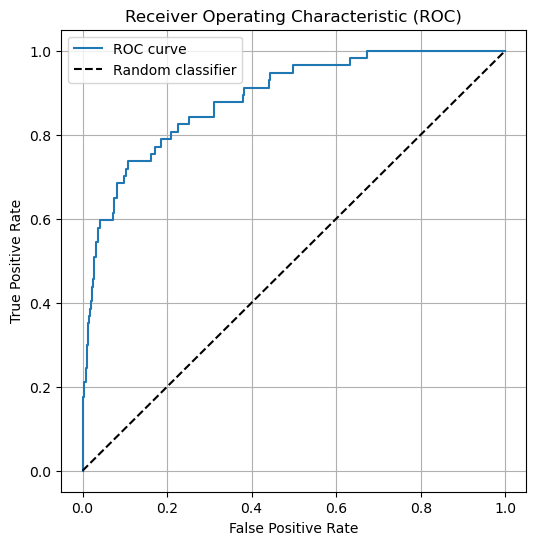

In [34]:

fpr, tpr, thresholds = roc_curve(Y_true, Y_pred)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.grid(True)

plt.show()

In [31]:
clf.fit(X, Y)
train_auc = roc_auc_score(Y, clf.predict_proba(X)[:, 1])
train_auc

0.9460740220705997

In [71]:
IFP_frequencies['12Jun_rg']['4h2i_c_4_dimer_sdf']

NameError: name 'IFP_frequencies' is not defined

In [69]:
len(X.columns)

64

In [66]:
len(coef_mean)

64

In [65]:
coef_sd

array([0.12522606, 0.13866201, 0.10697918, 0.19564551, 0.17239743,
       0.1594048 , 0.30053954, 0.17028525, 0.10754288, 0.17396498,
       0.12994789, 0.14610517, 0.24760975, 0.14978595, 0.17143163,
       0.11482356, 0.33071363, 0.11932494, 0.17868824, 0.10923563,
       0.17924229, 0.18446152, 0.24798245, 0.12308302, 0.20019336,
       0.35228216, 0.2935391 , 0.13953994, 0.2482597 , 0.18144483,
       0.23109602, 0.21188133, 0.18413333, 0.19279504, 0.18974891,
       0.03718073, 0.23491889, 0.21625226, 0.25712117, 0.30173114,
       0.27802028, 0.14926469, 0.1715406 , 0.28110543, 0.16535252,
       0.19412527, 0.26063533, 0.17002502, 0.37578997, 0.07173096,
       0.20511093, 0.17103723, 0.21796989, 0.2447861 , 0.24481381,
       0.16848882, 0.09992842, 0.17204706, 0.07061262, 0.30356423,
       0.15843287, 0.18943656, 0.19153148, 0.14838314])

## Include IFP and docking scores

In [ ]:
IFP_dicts['12Jun_rg']['4h2i_c_1_dimer_sdf']['4h2i_c_1_dimer_true_actives.sdf'][1].columns